# Temperature Scaling

Effect of temperature scaling (calibration) on the **NN Combined** model's
test-set confidences. The model is calibrated with a single learned
temperature **T = 1.5783** (`best_model_calibrated.pt`); T > 1 softens the
softmax, pushing confidences **down**. Predictions carry two confidence
columns: `confidence_uncalibrated` (raw softmax max) and `confidence`
(after temperature scaling).

All temperature-related plots live here.

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)
SAVE_DPI = 300

plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 110,
        "savefig.dpi": SAVE_DPI,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.axisbelow": True,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
    }
)

# Calibration colour convention: grey = before scaling, orange = after.
BEFORE_COLOR = "#94a3b8"
AFTER_COLOR = "#f97316"
NN_COLOR = "#f97316"
CORRECT_COLOR = "#10b981"
INCORRECT_COLOR = "#ef4444"
NEUTRAL_COLOR = "#6b7280"

TEMPERATURE = 1.5783  # learned scalar in best_model_calibrated.pt


def save_plot(fig, filename: str) -> Path:
    path = PLOTS_DIR / filename
    fig.savefig(path, dpi=SAVE_DPI, bbox_inches="tight")
    return path


def plot_confidence_bins(ax, confidences, correct, title):
    """Side-by-side correct vs incorrect counts for 0.1-wide confidence bins."""
    bin_edges = np.linspace(0.0, 1.0, 11)
    bin_labels = [f"{lo:.1f}–{hi:.1f}" for lo, hi in zip(bin_edges[:-1], bin_edges[1:])]
    correct_counts, incorrect_counts = [], []
    for i, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        if i == len(bin_edges) - 2:
            mask = (confidences >= lo) & (confidences <= hi)
        else:
            mask = (confidences >= lo) & (confidences < hi)
        correct_counts.append(int(correct[mask].sum()))
        incorrect_counts.append(int((~correct)[mask].sum()))

    x = np.arange(len(bin_labels))
    bar_w = 0.36
    ax.bar(x - bar_w / 2, correct_counts, bar_w, label="Correct",
        color=CORRECT_COLOR, edgecolor="white")
    ax.bar(x + bar_w / 2, incorrect_counts, bar_w, label="Incorrect",
        color=INCORRECT_COLOR, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=45, ha="right")
    ax.set_title(title)
    ax.set_xlabel("Confidence bin")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
    ax.legend()


def reliability(conf, correct, n_bins=15):
    """Equal-width reliability stats + expected calibration error (ECE)."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    accs, confs, counts = [], [], []
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        mask = (conf >= lo) & (conf <= hi) if i == 0 else (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            accs.append(np.nan); confs.append(np.nan); counts.append(0)
            continue
        accs.append(correct[mask].mean())
        confs.append(conf[mask].mean())
        counts.append(int(mask.sum()))
    accs, confs, counts = np.array(accs), np.array(confs), np.array(counts)
    ece = np.nansum(counts * np.abs(accs - confs)) / counts.sum()
    return edges, accs, confs, counts, ece

## Load test-set predictions

In [38]:
model_test = pd.read_csv("../benchmark/test_set/nn_combined_run/predictions.csv")
if "confidence_uncalibrated" not in model_test.columns:
    raise RuntimeError(
        "Missing confidence_uncalibrated — re-run: "
        "uv run toxfam eval model test_set --model-dir model/model_output/combined_run"
    )

nn_correct = (model_test["actual_label"] == model_test["predicted_label"]).to_numpy()
conf_before = model_test["confidence_uncalibrated"].to_numpy()
conf_after = model_test["confidence"].to_numpy()
delta = conf_after - conf_before

print(f"n = {len(model_test)}  |  accuracy = {nn_correct.mean():.4f}  |  T = {TEMPERATURE}")
print(f"mean confidence: before = {conf_before.mean():.4f}, after = {conf_after.mean():.4f}")
model_test.head()

n = 9779  |  accuracy = 0.9898  |  T = 1.5783
mean confidence: before = 0.9962, after = 0.9906


,identifier,actual_label,predicted_label,confidence,confidence_uncalibrated
0,P01502,other,other,0.990660,0.999581
1,A6YPK1,CRISP family,CRISP family,0.927131,0.984318
2,Q7ZTA0,CRISP family,CRISP family,0.999888,1.000000
3,Q8JI38,CRISP family,CRISP family,0.999870,1.000000
4,A6MFK9,CRISP family,CRISP family,0.999845,1.000000


## 1. Confidence distribution: before vs after

**Shows:** Overlaid histograms (log y-axis) of the model's max-softmax confidence
across all 9,779 test predictions — grey before scaling, orange after — with each
distribution's mean marked by a dashed vertical line.

**Message:** Temperature scaling (T = 1.58) softens every softmax, so the whole
distribution shifts left: the tall pile of near-certain predictions at ≈1.0 thins
out and the mean confidence drops from 0.996 to 0.991. This is the before/after
overview that every later plot dissects.

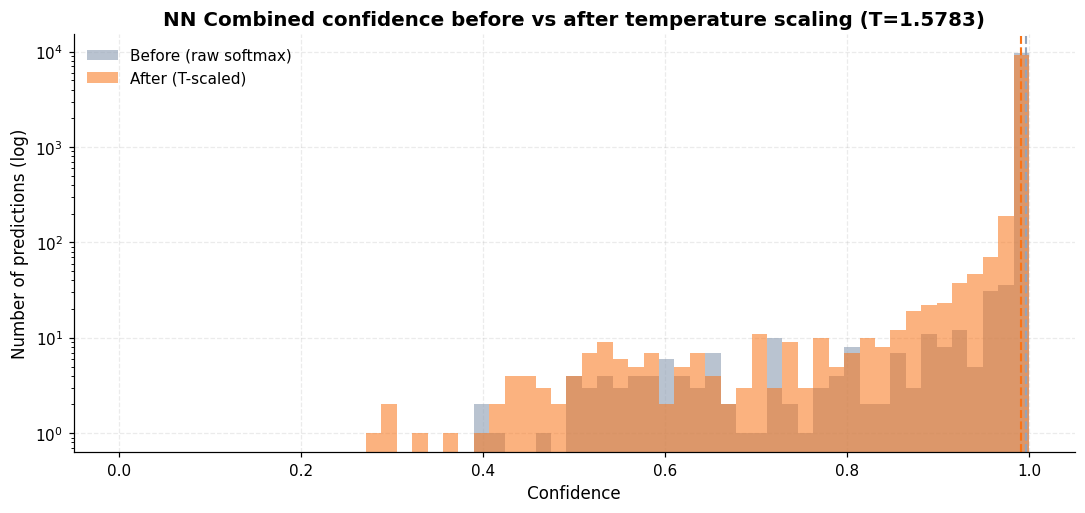

In [39]:
fig, ax = plt.subplots(figsize=(10, 4.8))
bins = np.linspace(0, 1, 60)
ax.hist(conf_before, bins=bins, color=BEFORE_COLOR, alpha=0.65, label="Before (raw softmax)")
ax.hist(conf_after, bins=bins, color=AFTER_COLOR, alpha=0.55, label="After (T-scaled)")
ax.axvline(conf_before.mean(), color=BEFORE_COLOR, linestyle="--", lw=1.4)
ax.axvline(conf_after.mean(), color=AFTER_COLOR, linestyle="--", lw=1.4)
ax.set_yscale("log")
ax.set_xlabel("Confidence")
ax.set_ylabel("Number of predictions (log)")
ax.set_title(f"NN Combined confidence before vs after temperature scaling (T={TEMPERATURE})")
ax.legend()
plt.tight_layout()
save_plot(fig, "temp_confidence_distribution_before_after.png")
plt.show()

## 2. Bin-count change from scaling (after − before)

**Shows:** The 0–1 confidence range split into ten 0.1-wide bins; each bar is the
*change* in the number of predictions in that bin (after minus before), shown
separately for correct (green) and incorrect (red) predictions. Positive = scaling
moved predictions **into** the bin, negative = **out of** it.

**Message:** The redistribution is concentrated at the top. Scaling drains the
highest bin (0.9–1.0) and refills the bins just below it — confidence is shifted
*down a notch*, not scattered across the range.

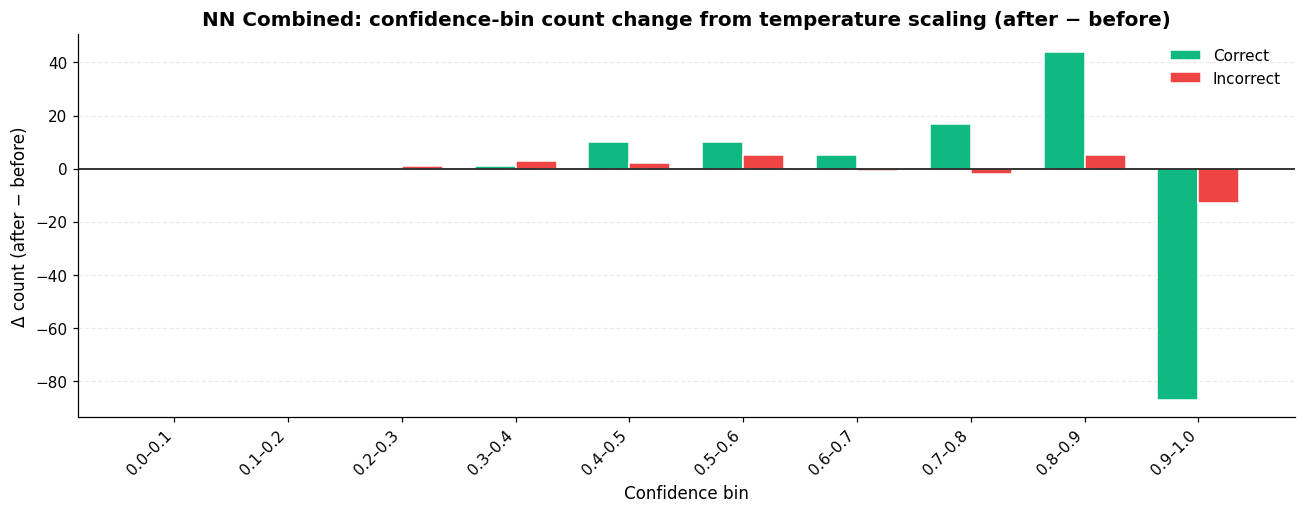

In [40]:
bin_edges = np.linspace(0.0, 1.0, 11)
bin_labels = [f"{lo:.1f}–{hi:.1f}" for lo, hi in zip(bin_edges[:-1], bin_edges[1:])]


def _bin_counts(confidences, correct):
    conf = np.asarray(confidences)
    cc, ic = [], []
    for i, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        mask = (conf >= lo) & (conf <= hi) if i == len(bin_edges) - 2 else (conf >= lo) & (conf < hi)
        cc.append(int(correct[mask].sum()))
        ic.append(int((~correct)[mask].sum()))
    return np.array(cc), np.array(ic)


before_correct, before_incorrect = _bin_counts(conf_before, nn_correct)
after_correct, after_incorrect = _bin_counts(conf_after, nn_correct)
delta_correct = after_correct - before_correct
delta_incorrect = after_incorrect - before_incorrect

x = np.arange(len(bin_labels))
bar_w = 0.36
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.bar(x - bar_w / 2, delta_correct, bar_w, label="Correct", color=CORRECT_COLOR, edgecolor="white")
ax.bar(x + bar_w / 2, delta_incorrect, bar_w, label="Incorrect", color=INCORRECT_COLOR, edgecolor="white")
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")
ax.set_title("NN Combined: confidence-bin count change from temperature scaling (after − before)")
ax.set_xlabel("Confidence bin")
ax.set_ylabel("Δ count (after − before)")
ax.grid(axis="x", visible=False)
ax.legend()
plt.tight_layout()
save_plot(fig, "temp_bin_count_delta.png")
plt.show()

## 3. Per-prediction confidence shift (density)

**Shows:** For every prediction, the signed shift Δ = calibrated − uncalibrated
confidence, as a fine density histogram (log y-axis) split into correct (green) and
incorrect (red), with each group's median marked by a dashed line.

**Message:** The key result. Both groups lose confidence (everything sits left of
zero), but **incorrect predictions are pulled down far harder than correct ones** —
their median drop (−0.052) is ~60× the correct group's (−0.0009). Good calibration
strips confidence preferentially from the predictions that were actually wrong.
The view is dense, though; plot 6 re-states it more legibly.

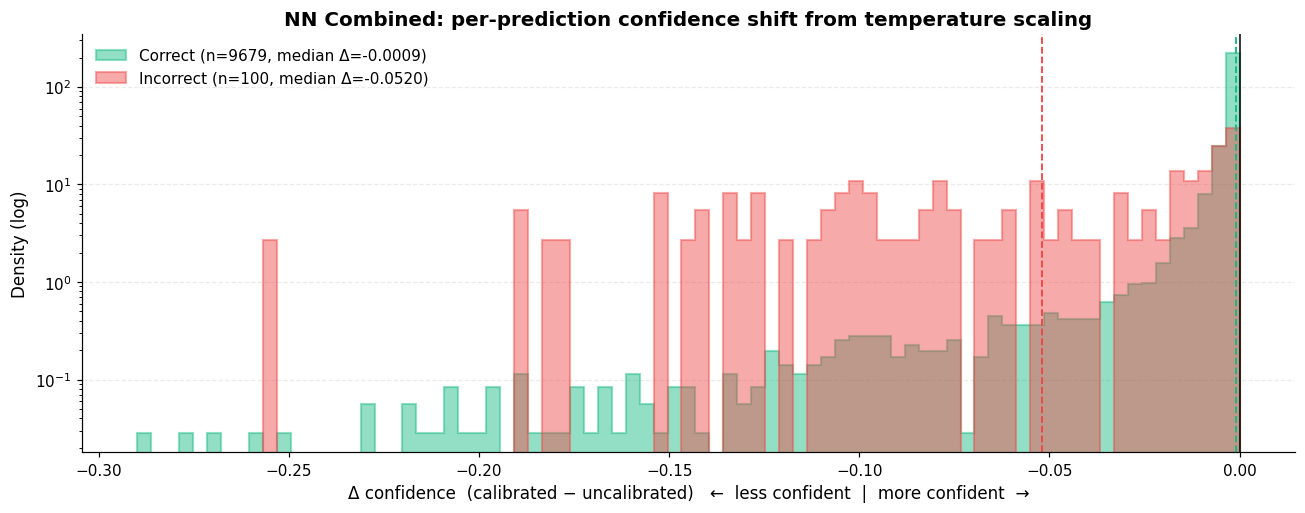

Mean Δ: correct=-0.0050, incorrect=-0.0626
Fraction pushed down (Δ<0): correct=0.999, incorrect=1.000


In [41]:
delta_correct_v = delta[nn_correct]
delta_incorrect_v = delta[~nn_correct]

lo, hi = delta.min(), delta.max()
bins = np.linspace(lo, hi, 80)

fig, ax = plt.subplots(figsize=(12, 4.8))
for d, color, label in [
    (delta_correct_v, CORRECT_COLOR, "Correct"),
    (delta_incorrect_v, INCORRECT_COLOR, "Incorrect"),
]:
    ax.hist(d, bins=bins, density=True, histtype="stepfilled", color=color,
            alpha=0.45, edgecolor=color, linewidth=1.4,
            label=f"{label} (n={len(d)}, median Δ={np.median(d):+.4f})")
    ax.axvline(np.median(d), color=color, linestyle="--", linewidth=1.2)

ax.axvline(0, color="black", linewidth=1)
ax.set_yscale("log")
ax.set_title("NN Combined: per-prediction confidence shift from temperature scaling")
ax.set_xlabel("Δ confidence  (calibrated − uncalibrated)   ←  less confident  |  more confident  →")
ax.set_ylabel("Density (log)")
ax.grid(axis="x", visible=False)
ax.legend()
plt.tight_layout()
save_plot(fig, "temp_per_prediction_shift_density.png")
plt.show()

print(f"Mean Δ: correct={delta_correct_v.mean():+.4f}, incorrect={delta_incorrect_v.mean():+.4f}")
print(f"Fraction pushed down (Δ<0): correct={(delta_correct_v < 0).mean():.3f}, "
      f"incorrect={(delta_incorrect_v < 0).mean():.3f}")

## 4. Where the shift happens: Δ vs original confidence

**Shows:** A scatter of each prediction's shift Δ against its *original*
(uncalibrated) confidence, coloured by correct (green) / incorrect (red).

**Message:** The shift is a smooth, near-deterministic function of starting
confidence: predictions already at ≈1.0 barely move, while mid-confidence
predictions drop the most. The vertical spread at a fixed x exists because the
shift depends on the *entire* logit vector, not just the max — so two predictions
with the same top confidence can move by different amounts.

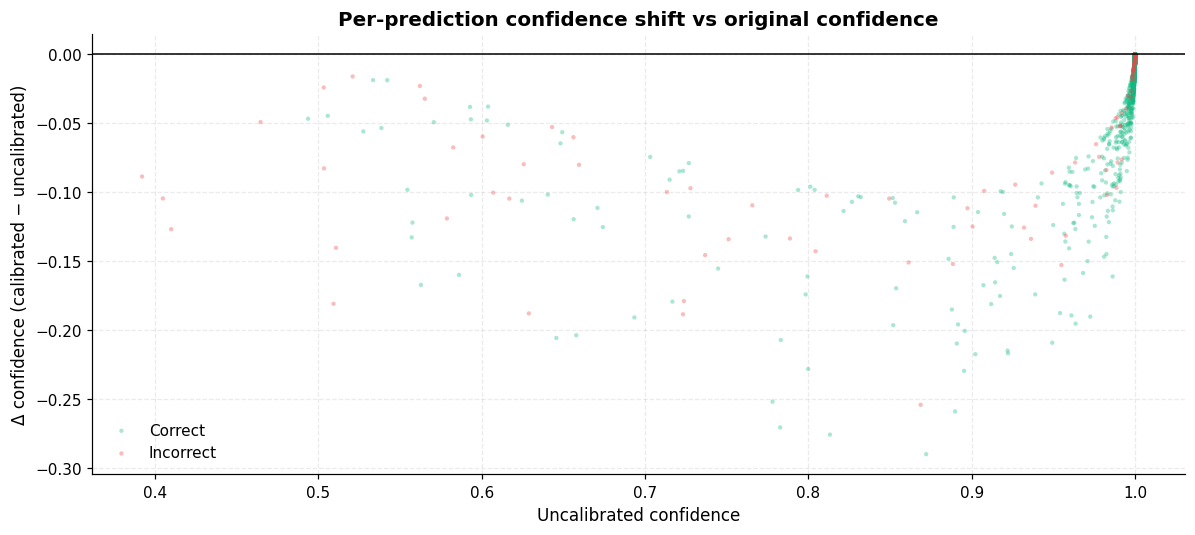

In [42]:
fig, ax = plt.subplots(figsize=(11, 5))
for m, color, label in [(nn_correct, CORRECT_COLOR, "Correct"), (~nn_correct, INCORRECT_COLOR, "Incorrect")]:
    ax.scatter(conf_before[m], delta[m], s=8, alpha=0.35, color=color, edgecolor="none", label=label)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Uncalibrated confidence")
ax.set_ylabel("Δ confidence (calibrated − uncalibrated)")
ax.set_title("Per-prediction confidence shift vs original confidence")
ax.legend(loc="lower left")
plt.tight_layout()
save_plot(fig, "temp_shift_vs_original_confidence.png")
plt.show()

## 5. Reliability diagram + ECE

**Shows:** Accuracy vs mean confidence within 15 equal-width bins; the dashed
diagonal is perfect calibration (confidence = accuracy). The lower panel shows how
many predictions fall in each bin (log scale). The expected calibration error (ECE)
— the population-weighted average gap between the curve and the diagonal — is in
the legend.

**Message:** Temperature scaling roughly **halves the ECE** (0.0071 → 0.0036). A
point below the diagonal means over-confidence; scaling moves the curve toward it.
Because almost every prediction lives in the top confidence bins (lower panel),
that headline number is dominated by the high-confidence region — which is exactly
what plot 5b zooms into.

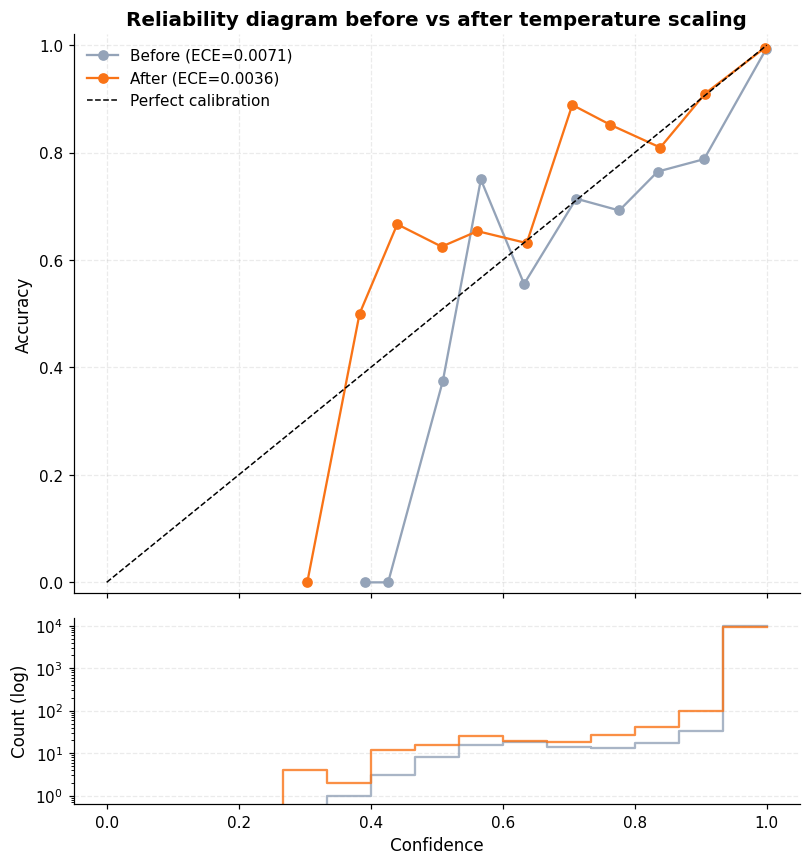

In [43]:
fig, (ax, axc) = plt.subplots(
    2, 1, figsize=(7.5, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
edges = np.linspace(0, 1, 16)
for conf, color, lab in [(conf_before, BEFORE_COLOR, "Before"), (conf_after, AFTER_COLOR, "After")]:
    _, accs, confs, counts, ece = reliability(conf, nn_correct, n_bins=15)
    ax.plot(confs, accs, marker="o", color=color, label=f"{lab} (ECE={ece:.4f})")
    axc.step(edges, np.append(counts, counts[-1]), where="post", color=color, alpha=0.8)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.set_ylabel("Accuracy")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Reliability diagram before vs after temperature scaling")
ax.legend(loc="upper left")
axc.set_yscale("log")
axc.set_ylabel("Count (log)")
axc.set_xlabel("Confidence")
axc.grid(axis="x", visible=False)
plt.tight_layout()
save_plot(fig, "temp_reliability_diagram.png")
plt.show()

### 5b. Reliability diagram, high-confidence region [0.9, 1.0]

**Shows:** The same reliability curves, restricted to confidence ∈ [0.9, 1.0] with
finer bins.

**Message:** Since nearly all predictions sit above 0.9, this is where calibration
actually matters for this model. The uncalibrated curve sits below the diagonal
(over-confident); after scaling it moves toward it.

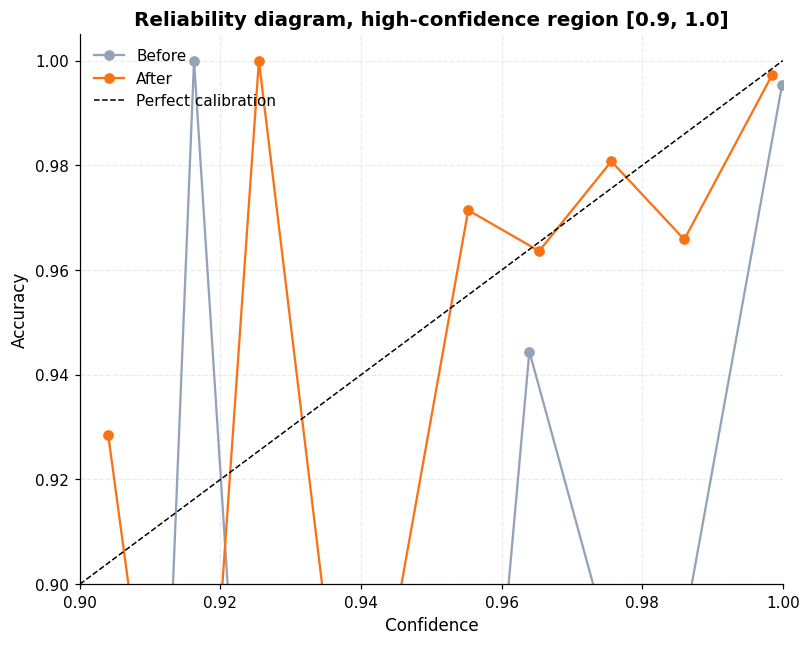

In [44]:
fig, ax = plt.subplots(figsize=(7.5, 6))
hi_edges = np.linspace(0.9, 1.0, 11)
hi_centers = (hi_edges[:-1] + hi_edges[1:]) / 2
for conf, color, lab in [(conf_before, BEFORE_COLOR, "Before"), (conf_after, AFTER_COLOR, "After")]:
    accs, confs = [], []
    for i, (lo, hi) in enumerate(zip(hi_edges[:-1], hi_edges[1:])):
        mask = (conf >= lo) & (conf <= hi) if i == 0 else (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            accs.append(np.nan); confs.append(np.nan); continue
        accs.append(nn_correct[mask].mean()); confs.append(conf[mask].mean())
    ax.plot(confs, accs, marker="o", color=color, label=lab)
ax.plot([0.9, 1.0], [0.9, 1.0], "k--", lw=1, label="Perfect calibration")
ax.set_xlim(0.9, 1.0)
ax.set_ylim(0.9, 1.005)
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Reliability diagram, high-confidence region [0.9, 1.0]")
ax.legend(loc="upper left")
plt.tight_layout()
save_plot(fig, "temp_reliability_diagram_zoom.png")
plt.show()

## 6. Selective calibration, made readable

Plots 3 and 5 carry the two headline messages but are dense (a log-density
histogram and a reliability diagram). The two plots below are cleaner reframings of
the same data, each stating one message in a single glance.

### 6a. Confidence drop by correctness (box plot)

**Shows:** The per-prediction shift Δ from plot 3, but as a box-and-whisker plot
with a jittered point overlay — correct vs incorrect — with each median labelled.

**Message:** The selective drop is obvious at a glance: the incorrect box sits far
below the correct box (median −0.052 vs −0.0009, ~60× larger). The same fact as
plot 3, read in one look instead of off a log-density curve.

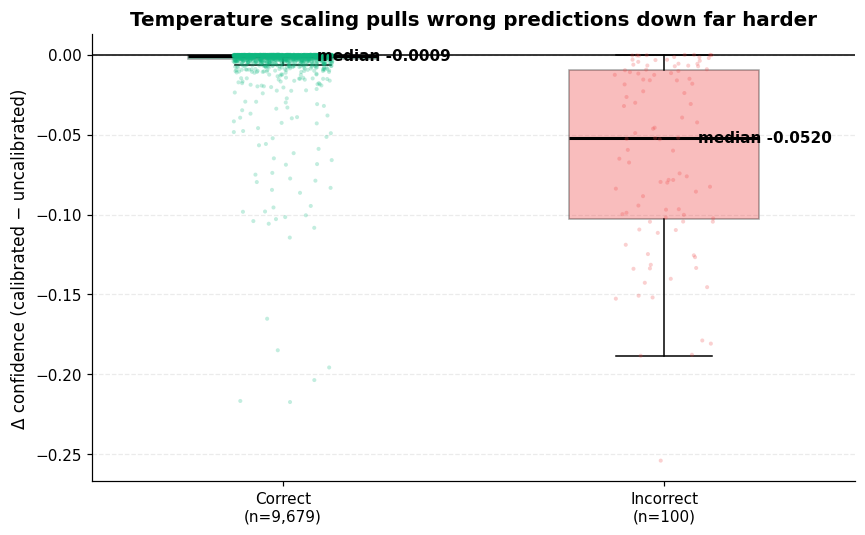

median Δ: correct -0.0009, incorrect -0.0520 (59× larger)


In [45]:
# 6a. Clean version of plot 3: the confidence drop (Δ = calibrated −
# uncalibrated) as a box plot with a jittered point overlay, correct vs
# incorrect. Same data as the log-density histogram, but the gap between the
# two medians is immediately legible.
groups = [delta[nn_correct], delta[~nn_correct]]
colors = [CORRECT_COLOR, INCORRECT_COLOR]
labels = [f"Correct\n(n={int(nn_correct.sum()):,})",
          f"Incorrect\n(n={int((~nn_correct).sum()):,})"]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(groups, positions=[0, 1], widths=0.5, showfliers=False,
                patch_artist=True, medianprops=dict(color="black", lw=2))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.35)

rng = np.random.default_rng(0)
for i, (g, c) in enumerate(zip(groups, colors)):
    idx = rng.choice(len(g), size=min(len(g), 1500), replace=False)
    ax.scatter(i + rng.uniform(-0.13, 0.13, size=len(idx)), g[idx],
               s=7, color=c, alpha=0.25, edgecolor="none", zorder=3)
    med = float(np.median(g))
    ax.annotate(f"median {med:+.4f}", (i, med), textcoords="offset points",
                xytext=(22, 0), va="center", fontsize=10, fontweight="bold")

ax.axhline(0, color="black", lw=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(labels)
ax.set_ylabel("Δ confidence (calibrated − uncalibrated)")
ax.set_title("Temperature scaling pulls wrong predictions down far harder")
ax.grid(axis="x", visible=False)
plt.tight_layout()
save_plot(fig, "temp_delta_box_by_correctness.png")
plt.show()

print(f"median Δ: correct {np.median(groups[0]):+.4f}, "
      f"incorrect {np.median(groups[1]):+.4f} "
      f"({np.median(groups[1]) / np.median(groups[0]):.0f}× larger)")

### 6b. Mean confidence vs the ideal (before / after)

**Shows:** Mean confidence for each group before (grey) and after (orange) scaling,
with a dotted cap at each group's *ideal* confidence — which is just its accuracy:
1.0 for correct predictions, 0.0 for incorrect ones. The Δ above each pair is the
mean shift.

**Message:** Bridges plots 3 and 5. Calibration barely touches the correct group
(already near its ideal of 1.0) while pulling the incorrect group's mean confidence
down ~12× harder, toward its ideal of 0. Confidence is moved in the right
direction, and overwhelmingly for the predictions that were wrong.

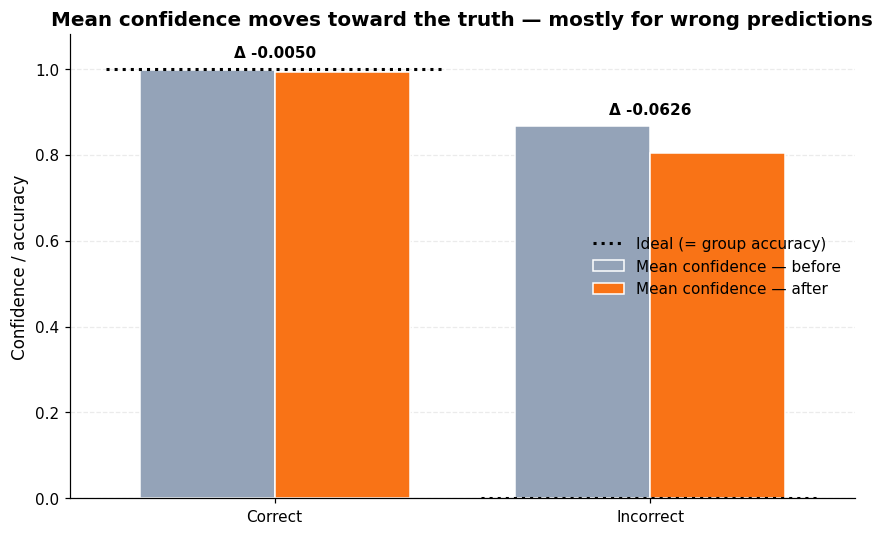

Correct:   confidence 0.9976 -> 0.9926 (Δ -0.0050)
Incorrect: confidence 0.8662 -> 0.8036 (Δ -0.0626)


In [46]:
# 6b. Combines plot 3 (selective drop) with plot 5 (move toward accuracy).
# For each group the *ideal* confidence equals its accuracy: 1.0 for the
# correct predictions, 0.0 for the incorrect ones. Bars = mean confidence
# before/after; dotted caps = that ideal. Calibration moves the wrong group's
# confidence down toward 0 far more than it touches the correct group.
masks = [nn_correct, ~nn_correct]
groups = ["Correct", "Incorrect"]
before_means = [conf_before[m].mean() for m in masks]
after_means = [conf_after[m].mean() for m in masks]
ideal = [1.0, 0.0]  # = group accuracy by definition

x = np.arange(len(groups))
w = 0.36
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w / 2, before_means, w, color=BEFORE_COLOR, edgecolor="white",
       label="Mean confidence — before")
ax.bar(x + w / 2, after_means, w, color=AFTER_COLOR, edgecolor="white",
       label="Mean confidence — after")
ax.hlines(ideal, x - 0.45, x + 0.45, color="black", linestyle=":", lw=2,
          label="Ideal (= group accuracy)")

for xi, bef, aft in zip(x, before_means, after_means):
    ax.annotate(f"Δ {aft - bef:+.4f}", (xi, max(bef, aft)),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Confidence / accuracy")
ax.set_title("Mean confidence moves toward the truth — mostly for wrong predictions")
ax.grid(axis="x", visible=False)
ax.legend(loc="center right")
plt.tight_layout()
save_plot(fig, "temp_mean_confidence_vs_accuracy.png")
plt.show()

print(f"Correct:   confidence {before_means[0]:.4f} -> {after_means[0]:.4f} "
      f"(Δ {after_means[0]-before_means[0]:+.4f})")
print(f"Incorrect: confidence {before_means[1]:.4f} -> {after_means[1]:.4f} "
      f"(Δ {after_means[1]-before_means[1]:+.4f})")

## 7. Summary table

The headline numbers behind every plot above, before vs after temperature scaling:
mean and median confidence, ECE (15 equal-width bins), and the median
per-prediction shift Δ for correct vs incorrect predictions. The `after` column has
no Δ rows because Δ is itself the before→after change. Confirms the two takeaways
numerically — ECE halves (0.0071 → 0.0036), and the wrong predictions' median drop
(−0.052) dwarfs the correct ones' (−0.0009).

In [47]:
_, _, _, _, ece_before = reliability(conf_before, nn_correct, n_bins=15)
_, _, _, _, ece_after = reliability(conf_after, nn_correct, n_bins=15)

summary = pd.DataFrame(
    {
        "before": [conf_before.mean(), np.median(conf_before), ece_before,
                   np.median(delta[nn_correct]), np.median(delta[~nn_correct])],
        "after": [conf_after.mean(), np.median(conf_after), ece_after, np.nan, np.nan],
    },
    index=["mean confidence", "median confidence", "ECE (15 bins)",
           "median Δ (correct)", "median Δ (incorrect)"],
)
print(f"Temperature T = {TEMPERATURE}")
print(f"ECE reduced {ece_before:.4f} → {ece_after:.4f} "
      f"({100 * (1 - ece_after / ece_before):.0f}% lower)")
summary

Temperature T = 1.5783
ECE reduced 0.0071 → 0.0036 (50% lower)


,before,after
mean confidence,0.996234,0.990625
median confidence,0.999996,0.999102
ECE (15 bins),0.007068,0.003561
median Δ (correct),-0.000878,NaN
median Δ (incorrect),-0.052030,NaN
